In [2]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 88.5 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 71.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]2/3 [catboost]
Note: you may need to restart the kernel to use updated packages.


>>> Wczytano wektor kwantowy (CatBoost) o kształcie (563, 15)

>>> Start optymalizacji Walk-Forward (CatBoost)...

--- WYNIKI CATBOOST OOS ---
Accuracy: 0.5245 (Thresh = 0.50)
AUC ROC:  0.5354

--- ZNACZENIE OSI POMIAROWYCH (TOP 5) ---
1. Q1_HUB_X: 9.4805
2. Q3_Sat_X: 8.7452
3. Q0_Sat_Z: 8.4448
4. Q2_Sat_X: 8.0572
5. Q2_Sat_Y: 7.8368


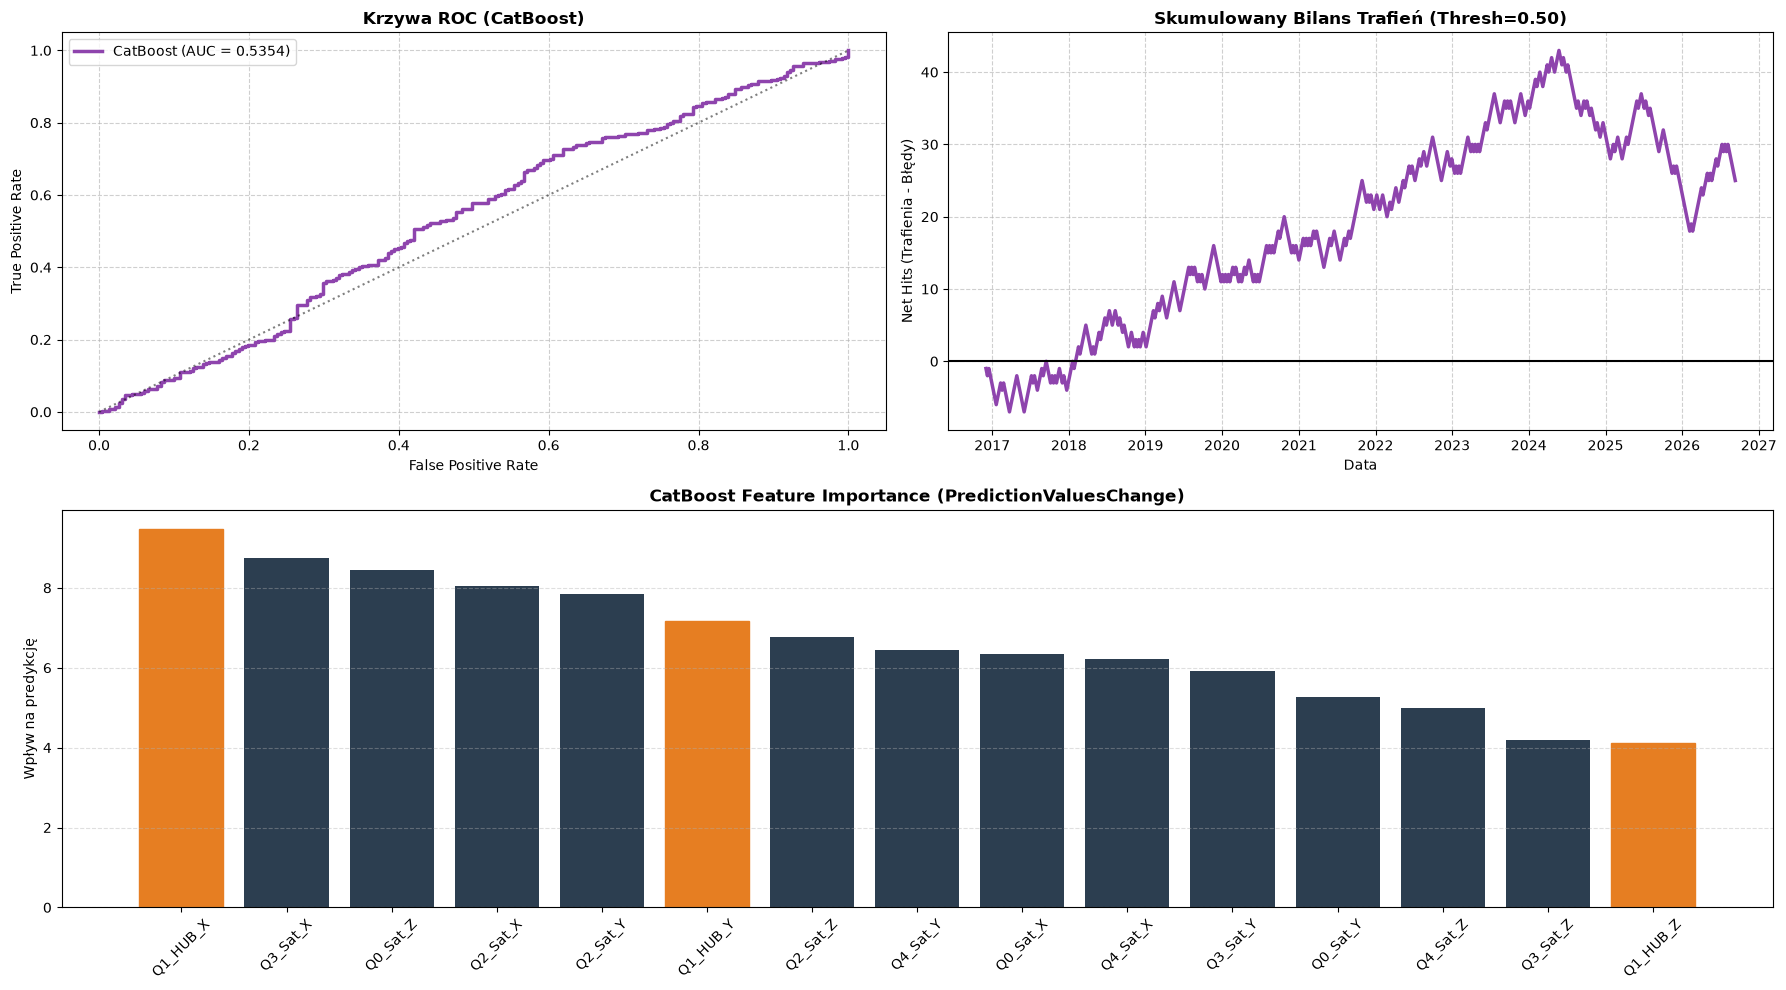

In [4]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA PLIKÓW I DANYCH
# ==========================================
PLIK_KACHE = "phi_odra_Top5_Rank1_Opt_q1_0.86_1.00_0.80_0.27_0.95.npz" 
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
y = y_raw[LOOKBACK:]
dates = dates_raw[LOOKBACK:]

if not os.path.exists(PLIK_KACHE):
    raise FileNotFoundError(f"Nie znaleziono pliku {PLIK_KACHE}.")

loaded_archive = np.load(PLIK_KACHE, allow_pickle=True)
first_key = loaded_archive.files[0]
Phi_real = loaded_archive[first_key]

print(f">>> Wczytano wektor kwantowy (CatBoost) o kształcie {Phi_real.shape}")

FEATURE_NAMES = [
    "Q0_Sat_X", "Q0_Sat_Y", "Q0_Sat_Z",
    "Q1_HUB_X", "Q1_HUB_Y", "Q1_HUB_Z",
    "Q2_Sat_X", "Q2_Sat_Y", "Q2_Sat_Z",
    "Q3_Sat_X", "Q3_Sat_Y", "Q3_Sat_Z",
    "Q4_Sat_X", "Q4_Sat_Y", "Q4_Sat_Z"
]

# ==========================================
# 2. TRENOWANIE KROCZĄCE: CATBOOST
# ==========================================
print("\n>>> Start optymalizacji Walk-Forward (CatBoost)...")

TRAIN_WINDOW = 52
results = {"y_true": [], "dates": [], "prob": []}
feature_importances_history = []

# Konfiguracja CatBoost nastawiona na tłumienie szumu kwantowego (mocna regularyzacja)
# Brak konieczności GridSearchCV, CatBoost jest wysoce odporny "out-of-the-box"
cb_params = {
    "iterations": 100,           # Płytki cykl uczenia, żeby nie overfitować szumu
    "depth": 3,                  # Symetryczne, bardzo płytkie drzewa (szukanie ogólnych wzorców)
    "l2_leaf_reg": 5,            # Mocna kara za zbyt skomplikowane granice decyzyjne
    "learning_rate": 0.05,
    "verbose": False,
    "random_seed": 42
}

for t in range(TRAIN_WINDOW, len(y)):
    X_tr, X_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # Inicjalizacja i trening modelu
    model = CatBoostClassifier(**cb_params)
    model.fit(X_tr, y_tr)
    
    # Predykcja out-of-sample
    results["prob"].append(model.predict_proba(X_te)[0, 1])
    
    # Archiwizacja ważności cech z danego kroku
    feature_importances_history.append(model.get_feature_importance())

y_true = np.array(results["y_true"])
prob_preds = np.array(results["prob"])

# SZTYWNY PRÓG 0.50 
final_preds = (prob_preds > 0.55).astype(int)
acc = accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, prob_preds)

# ==========================================
# 3. ANALIZA WAŻNOŚCI CECH (PredictionValuesChange)
# ==========================================
avg_importances = np.mean(feature_importances_history, axis=0)

sorted_idx = np.argsort(avg_importances)[::-1]
sorted_features = [FEATURE_NAMES[i] for i in sorted_idx]
sorted_importances = avg_importances[sorted_idx]

print(f"\n--- WYNIKI CATBOOST OOS ---")
print(f"Accuracy: {acc:.4f} (Thresh = 0.50)")
print(f"AUC ROC:  {auc:.4f}")

print("\n--- ZNACZENIE OSI POMIAROWYCH (TOP 5) ---")
for i in range(5):
    print(f"{i+1}. {sorted_features[i]}: {sorted_importances[i]:.4f}")

# ==========================================
# 4. WIZUALIZACJA
# ==========================================
fig = plt.figure(figsize=(18, 10))
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 1, 2)

fpr, tpr, _ = roc_curve(y_true, prob_preds)
ax1.plot(fpr, tpr, color='#8e44ad', lw=2.5, label=f'CatBoost (AUC = {auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax1.set_title('Krzywa ROC (CatBoost)', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

net_hits = np.cumsum(np.where(final_preds == y_true, 1, -1))
ax2.plot(results["dates"], net_hits, color='#8e44ad', lw=2.5)
ax2.axhline(0, color='black', lw=1.5)
ax2.set_title('Skumulowany Bilans Trafień (Thresh=0.50)', fontweight='bold')
ax2.set_xlabel('Data')
ax2.set_ylabel('Net Hits (Trafienia - Błędy)')
ax2.grid(True, linestyle='--', alpha=0.6)

bars = ax3.bar(sorted_features, sorted_importances, color='#2c3e50')
for i, bar in enumerate(bars):
    if "HUB" in sorted_features[i]:
        bar.set_color('#e67e22') 
        
ax3.set_title('CatBoost Feature Importance (PredictionValuesChange)', fontweight='bold')
ax3.set_ylabel('Wpływ na predykcję')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()